In [55]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 소셜 광고 데이터 셋
[소셜 광고 데이터셋 링크](https://www.kaggle.com/datasets/akram24/social-network-ads?resource=download)

### 소셜 광고 데이터 셋 컬럼
| 컬럼명 (Column) | 데이터 타입 | 설명 (Description) |
| :--- | :--- | :--- |
| **User ID** | 정수형 (Int) | 유저 고유 식별 번호 (학습 시 제외) |
| **Gender** | 문자형 (String) | 유저의 성별 (Male / Female) |
| **Age** | 정수형 (Int) | 유저의 나이 |
| **EstimatedSalary** | 정수형 (Int) | 유저의 추정 연봉 |
| **Purchased** | 정수형 (Int) | 광고 물건 구매 여부 (0: 미구매, 1: 구매)|

In [3]:
base_path = r"E:\kdt_0900_sal\ml\resource\dataset"
file_name = r"social_ads.csv"
file_path = os.path.join(base_path, file_name)

In [4]:
df = pd.read_csv(file_path)
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


## 1단계, 데이터 전처리

In [6]:
# User ID: 삭제
# 수치형: Age, EstimatedSalary
# 분류형: User ID, Gender, Purchased
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


In [7]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [8]:
ads_df = df.drop("User ID", axis=1)
ads_df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [9]:
ads_df["Purchased"].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

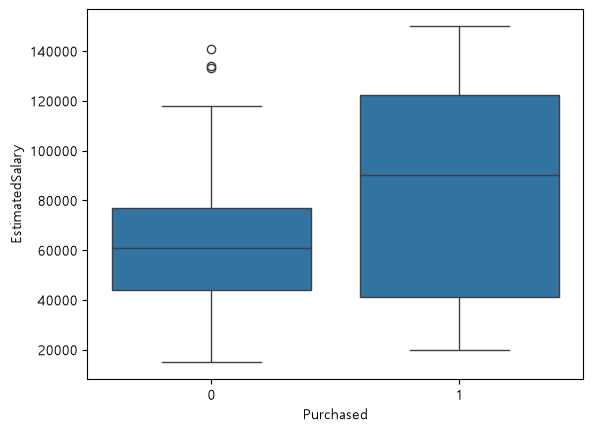

In [10]:
sns.boxplot(ads_df, x="Purchased", y="EstimatedSalary")
plt.show()

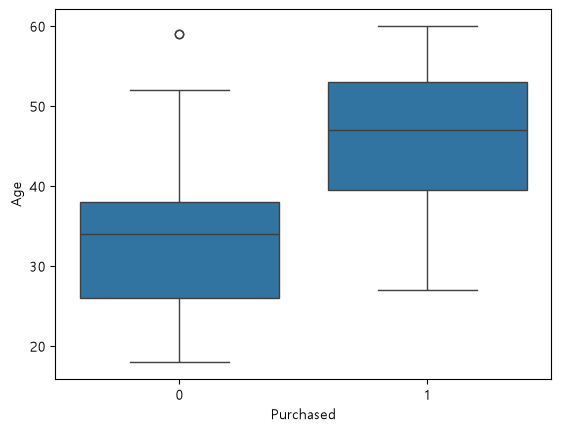

In [11]:
sns.boxplot(ads_df, x="Purchased", y="Age")
plt.show()

In [12]:
ads_df.head(1)

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0


In [15]:
ads_df = pd.get_dummies(ads_df, columns=["Gender"], dtype=int, drop_first=True)

In [17]:
ads_df.head()

,Age,EstimatedSalary,Purchased,Gender_Male
0,19,19000,0,1
1,35,20000,0,1
2,26,43000,0,0
3,27,57000,0,0
4,19,76000,0,1


In [20]:
X = ads_df.drop("Purchased", axis=1)
X.head(1)

,Age,EstimatedSalary,Gender_Male
0,19,19000,1


In [21]:
y = ads_df["Purchased"]
y.head(1)

0    0
Name: Purchased, dtype: int64

In [22]:
X.columns = ["Age", "Salary", "Gender"]

In [23]:
X.head()

,Age,Salary,Gender
0,19,19000,1
1,35,20000,1
2,26,43000,0
3,27,57000,0
4,19,76000,1


## 데이터 누수
- 데이터 셋을 나누고 스케일링을 해야하는 이유는 데이터 셋을 나누기 전에 전체 데이터를 스케일링하면  
  모델 학습 전에 학습시 절대 보면 안되는 테스트 데이터의 평균과 숫자들이 훈련 데이터셋에 야금야금 스며들어서 데이터 누수가 발생한다.

In [24]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)

In [25]:
# 1. 자르고 표준화한다
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2단계, 모델 준비

In [30]:
# Salary 연봉
X_train_salary = X_train_scaled[:, [1]]
X_test_salary = X_test_scaled[:, [1]]

In [31]:
# 선형회귀 모델(weight * x) + bias
# weight: 가중치
# bias: 절편
lr = LinearRegression()

In [32]:
lr.fit(X_train_salary, y_train)

LinearRegression()

In [34]:
print(f"선형 모델의 정확도: {lr.score(X_train_salary, y_train)}")

선형 모델의 정확도: 0.1408930349620512


## 결론 쓰레기

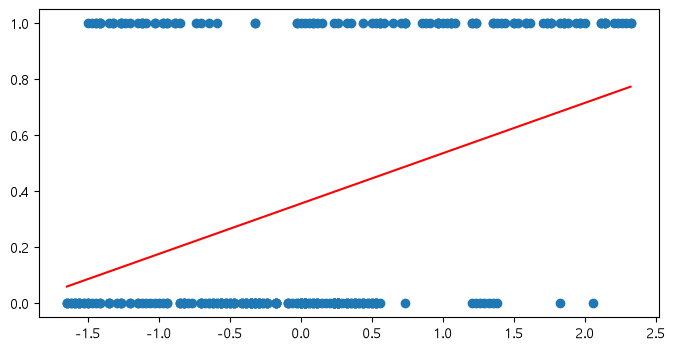

In [38]:
plt.figure(figsize=(8, 4))
plt.scatter(X_train_salary, y_train)

x_line = np.linspace(X_train_salary.min(), X_train_salary.max(), 100).reshape(-1, 1)
y_line = lr.predict(x_line)

plt.plot(x_line, y_line, color="red")
plt.show()

## 모델 준비

In [40]:
lr = LogisticRegression()

## 모델 학습

In [42]:
lr.fit(X_train_scaled, y_train)

LogisticRegression()

## 모델 예측

In [43]:
y_pred = lr.predict(X_test_scaled)
y_pred

array([1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0])

## 모델 평가

<img src="https://blog.kakaocdn.net/dna/beQKaR/btsQVxmfALT/AAAAAAAAAAAAAAAAAAAAAEN8Msuz4492U5M2pBZKQ2RtjEOY5OdH6q0btxI5Uurb/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1790780399&allow_ip=&allow_referer=&signature=7GgzV35irLeFkyH%2BGmsM6uW65LQ%3D" />

### 과적합(overfitting)
- 머신러닝 과적합은 모델이 학습 데이터에만 지나치게 최적화되는 현상을 의미합니다.  
  현재 데이터셋에 지나치게 맞춰지게 되면, 새로운 데이터가 들어왔을 대 예측 능력이 크게 떨어질 수 있습니다.  
  이런 현상을 과적합이라고 합니다.

In [46]:
print(f"훈련 데이터 점수: {lr.score(X_train_scaled, y_train)}")
print(f"테스트 데이터 점수: {accuracy_score(y_test, y_pred)}")

훈련 데이터 점수: 0.853125
테스트 데이터 점수: 0.7875


In [48]:
coef_df = pd.DataFrame({
    "Features": X_train.columns,
    "Coef": lr.coef_[0]
}).sort_values(by="Coef", ascending=False)

coef_df

,Features,Coef
0,Age,2.394875
1,Salary,1.161530
2,Gender,0.373889


In [49]:
"""
    소셜에서 상품을 구매할 때에는 연봉보다는 나이가 구매할 때의 영향을 많이 끼친 것으로 파악된다.
"""
None

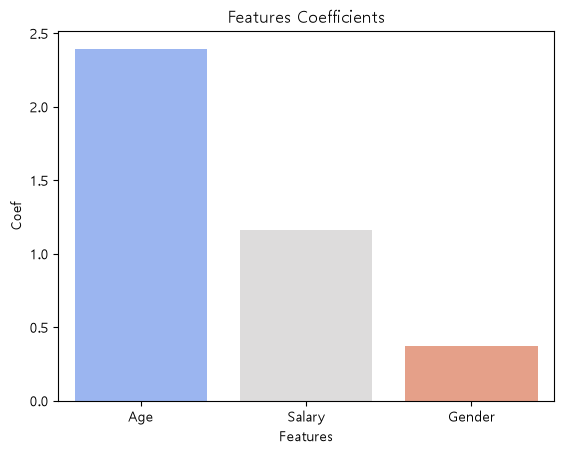

In [51]:
sns.barplot(coef_df, x="Features", y="Coef", hue="Features", palette="coolwarm")
plt.title("Features Coefficients")
plt.show()

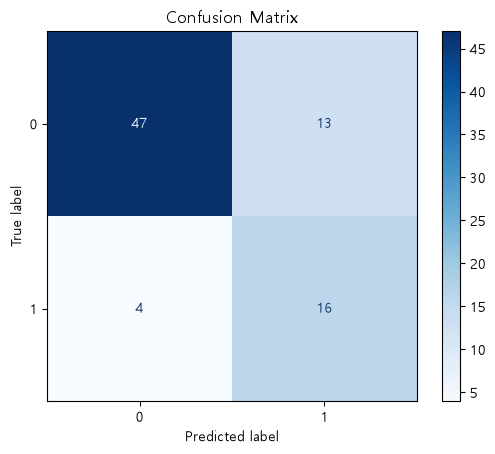

In [53]:
cm = confusion_matrix(y_pred, y_test)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# 대학원 합격 예측 데이터 셋
[대학원 합격 예측 데이터셋 링크](https://www.kaggle.com/datasets/mohansacharya/graduate-admissions)

## 컬럼 상세 설명
| 컬럼명 | 데이터 타입 | 데이터 범위 | 설명 |
| :--- | :--- | :--- | :--- |
| **`Serial No.`** | 정수 (Int) | $1 \sim 500$ | 학생 식별용 고유 번호 |
| **`GRE Score`** | 정수 (Int) | $290 \sim 340$ 점 | 미국 대학원 입학 시험(GRE) 점수 |
| **`TOEFL Score`** | 정수 (Int) | $92 \sim 120$ 점 | 공인 영어 능력 평가(TOEFL) 점수 |
| **`University Rating`** | 정수 (Int) | $1 \sim 5$ 단계 | 지원/출신 대학의 명성 레벨 ($1$: 낮음 $\sim$ $5$: 최고) |
| **`SOP`** | 실수 (Float) | $1.0 \sim 5.0$ 점 | 자기소개서/학업계획서(Statement of Purpose) 점수 |
| **`LOR`** | 실수 (Float) | $1.0 \sim 5.0$ 점 | 교수 추천서(Letter of Recommendation) 점수 |
| **`CGPA`** | 실수 (Float) | $6.80 \sim 9.92$ | 학부 평균 학점 (Cumulative GPA, 10점 만점 기준) |
| **`Research`** | 정수 (Int) | $0$ 또는 $1$ | 학부 연구 참여 및 논문 작성 경험 ($0$: 없음, $1$: 있음) |
| **`Chance of Admit`** | 정수 (Int) | $0$ 또는 $1$ | 합격 1, 불합격 0 |

In [56]:
base_path = r"E:\kdt_0900_sal\ml\resource\dataset"
file_name = r"admission_predict.csv"
file_path = os.path.join(base_path, file_name)

In [58]:
df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,0,1,337,118,4,4.5,4.5,9.65,1,1
1,1,2,324,107,4,4.0,4.5,8.87,1,1
2,2,3,316,104,3,3.0,3.5,8.00,1,0
3,3,4,322,110,3,3.5,2.5,8.67,1,1
4,4,5,314,103,2,2.0,3.0,8.21,0,0
